In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Load Dataset

The dataset is loaded into a Pandas DataFrame for further analysis.

Each row represents one student, while each column represents demographic, academic, lifestyle, financial, behavioral, and psychological information.

In [2]:
# ==========================================================
# Load the Dataset
# ==========================================================
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("student_mental_health_burnout.csv")

# Display the first five records
df.head()

Saving student_mental_health_burnout.csv to student_mental_health_burnout.csv


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,risk_level
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,Low
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,Low
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,Low
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,High
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,Low


In [3]:
# ==========================================================
# Reduce Dataset Size for Efficient SVM Training
# ==========================================================

# Classical SVMs have high computational complexity on
# very large datasets. A random sample of 50,000 records
# is used to reduce training time while preserving the
# overall data distribution.

df = df.sample(
    n=50000,
    random_state=42
).reset_index(drop=True)

print("Reduced Dataset Shape:", df.shape)

Reduced Dataset Shape: (50000, 17)


# Dataset Overview

Before training any machine learning model, it is important to understand the dataset.

The following analysis provides:

- Number of rows and columns
- Feature names
- Data types
- Missing values
- Duplicate records
- Class distribution

In [4]:
# ==========================================================
# Basic Information about the Dataset
# ==========================================================

print("Dataset Shape :", df.shape)

print("\nColumn Names:\n")
print(df.columns)

print("\nDataset Information:\n")
df.info()

Dataset Shape : (50000, 17)

Column Names:

Index(['age', 'gender', 'academic_year', 'study_hours_per_day',
       'exam_pressure', 'academic_performance', 'stress_level',
       'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity',
       'social_support', 'screen_time', 'internet_usage', 'financial_stress',
       'family_expectation', 'risk_level'],
      dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   50000 non-null  int64  
 1   gender                50000 non-null  object 
 2   academic_year         50000 non-null  int64  
 3   study_hours_per_day   50000 non-null  float64
 4   exam_pressure         50000 non-null  float64
 5   academic_performance  50000 non-null  float64
 6   stress_level          50000 non-null  float64
 7   anxiety_

In [5]:
# ==========================================================
# Check Missing Values
# ==========================================================

print(df.isnull().sum())

age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
risk_level              0
dtype: int64


In [6]:
# ==========================================================
# Check Duplicate Records
# ==========================================================

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [7]:
# ==========================================================
# Summary Statistics
# ==========================================================

df.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,23.012260,2.501520,5.013562,6.008875,71.041004,4.255597,2.999632,1.275325,6.505493,3.008363,4.992785,5.021047,5.043737,5.005236,5.991639
std,3.735322,1.120082,1.981346,1.545556,5.642324,1.675860,1.513105,1.218341,1.475286,1.467358,1.974774,1.957154,2.148681,1.988006,1.950812
min,17.000000,1.000000,0.000000,1.000000,47.246335,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.000000,3.680842,4.956196,67.199770,3.104519,1.945358,0.012040,5.492874,1.978017,3.637245,3.643364,3.488534,3.650028,4.654957
50%,23.000000,3.000000,5.013920,6.015213,71.030736,4.255530,2.978128,1.048710,6.500727,2.994164,4.987985,5.000181,5.009370,5.006565,6.013891
75%,26.000000,4.000000,6.334322,7.063172,74.869904,5.395759,4.027335,2.093756,7.519623,4.016478,6.339446,6.345601,6.499970,6.367445,7.360769
max,29.000000,4.000000,13.227433,10.000000,94.457995,10.000000,9.107460,7.856146,10.000000,7.000000,10.000000,12.000000,13.900386,10.000000,10.000000


# Exploratory Data Analysis (EDA)

EDA helps in understanding the distribution of the data, identifying relationships between variables, detecting outliers, and analyzing class imbalance before building the machine learning models.

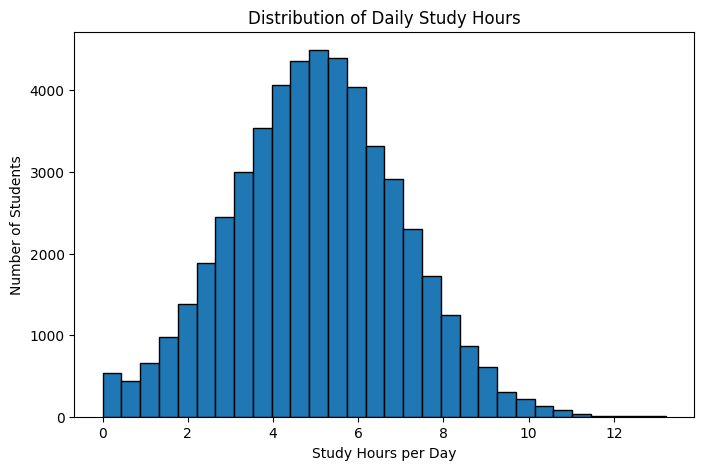

In [8]:
# ==========================================================
# Distribution of Study Hours
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    df["study_hours_per_day"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Daily Study Hours")
plt.xlabel("Study Hours per Day")
plt.ylabel("Number of Students")

plt.show()

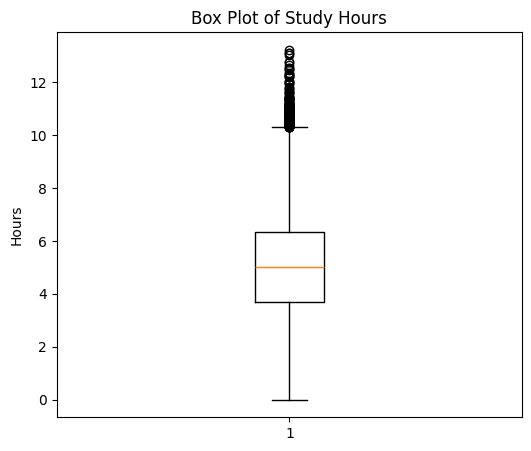

In [9]:
# ==========================================================
# Detect Outliers in Study Hours
# ==========================================================

plt.figure(figsize=(6,5))

plt.boxplot(df["study_hours_per_day"])

plt.title("Box Plot of Study Hours")

plt.ylabel("Hours")

plt.show()

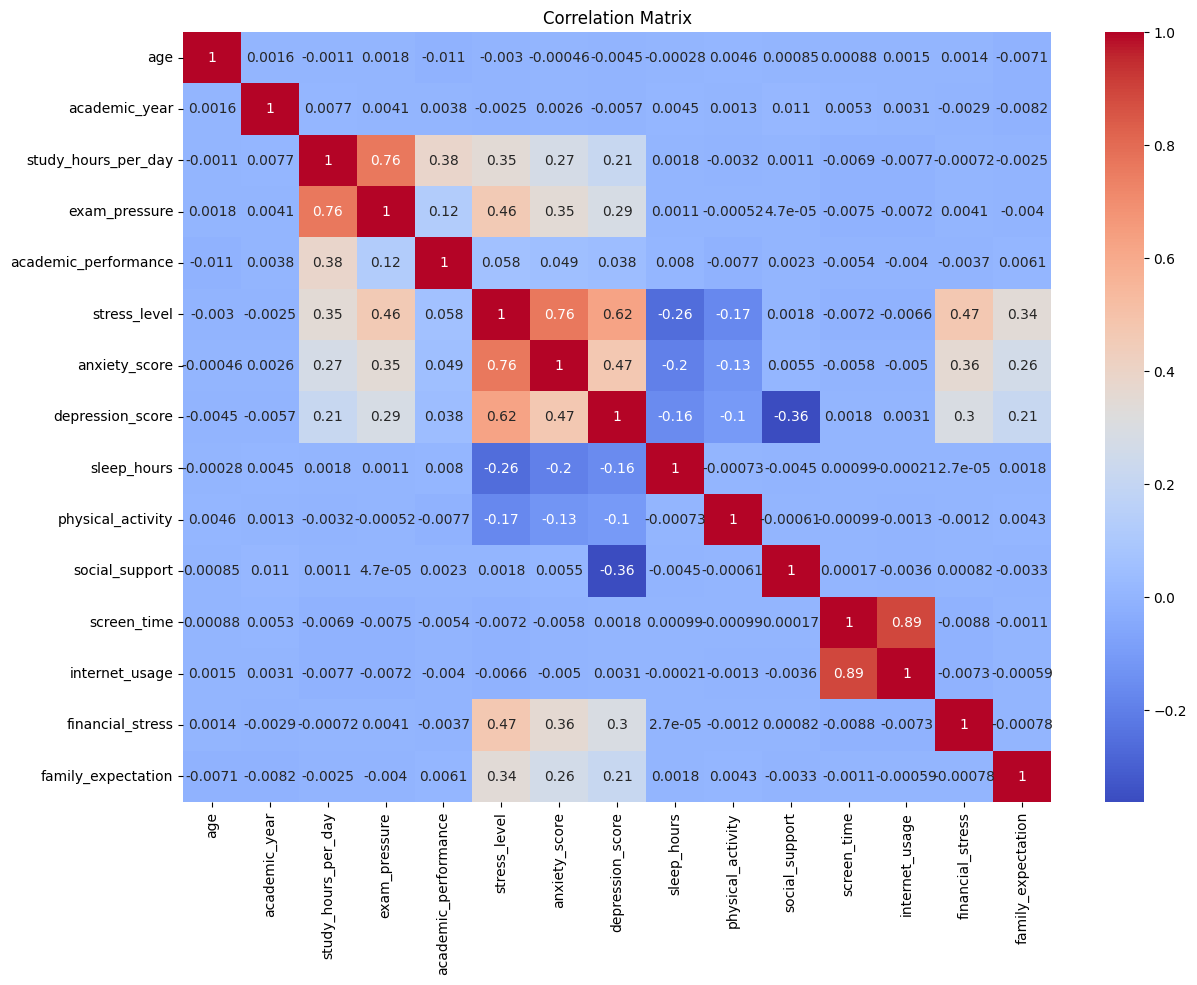

In [10]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [11]:
# ==========================================================
# Target Variable Distribution
# ==========================================================

print(df["risk_level"].value_counts())

print(df["risk_level"].value_counts(normalize=True))

risk_level
Low       38372
Medium    10886
High        742
Name: count, dtype: int64
risk_level
Low       0.76744
Medium    0.21772
High      0.01484
Name: proportion, dtype: float64


# Data Preprocessing

The dataset contains categorical variables that cannot be processed directly by SVM.

Therefore,

- The target variable is separated.
- Categorical features are encoded.
- Target labels are converted into numerical classes.

In [12]:
# ==========================================================
# Separate Features and Target Variable
# ==========================================================

X = df.drop(
    columns=[
        "risk_level"
    ]
)

y = df["risk_level"]

In [13]:
# ==========================================================
# Encode Categorical Feature
# ==========================================================

# Gender is a nominal categorical feature.
# One-Hot Encoding converts it into binary numerical columns.

X = pd.get_dummies(
    X,
    columns=["gender"],
    drop_first=True
)

In [14]:
# ==========================================================
# Encode Target Labels
# ==========================================================

# Burnout risk follows an ordinal relationship:
# Low < Medium < High

y = y.map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

# Train-Test Split

To evaluate how well the model generalizes to unseen data, the dataset is divided into training and testing sets.

- Training Set (80%) → Used to train the model.
- Testing Set (20%) → Used only for evaluation.

This prevents the model from memorizing the dataset and provides an unbiased estimate of performance.

In [15]:
# ==========================================================
# Split Dataset into Training and Testing Sets
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (40000, 17)
Testing Samples  : (10000, 17)


# Feature Scaling

Support Vector Machines are distance-based algorithms.

Features with larger numerical ranges can dominate the optimization process.

Therefore, all numerical features are standardized using **StandardScaler**, which transforms every feature to have:

- Mean = 0
- Standard Deviation = 1

The scaler is fitted **only on the training data** to prevent data leakage.

In [16]:
# ==========================================================
# Standardize Numerical Features
# ==========================================================

scaler = StandardScaler()

# Learn scaling parameters from the training data
X_train = scaler.fit_transform(X_train)

# Apply the same transformation to the testing data
X_test = scaler.transform(X_test)

# Model 1 — Linear Support Vector Machine

The first model uses a **Linear Kernel**.

This model assumes that the classes can be separated using a straight hyperplane.

It serves as the baseline model for comparison with more advanced variants.

In [17]:
# ==========================================================
# Train Linear SVM
# ==========================================================

linear_model = SVC(
    kernel="linear",
    C=1.0
)

linear_model.fit(X_train, y_train)

SVC(kernel='linear')

# Evaluate Linear SVM

The trained model is evaluated using:

- Accuracy
- Confusion Matrix
- Classification Report

These metrics help analyze the strengths and weaknesses of the classifier.

In [18]:
# ==========================================================
# Predictions using Linear SVM
# ==========================================================

y_pred_linear = linear_model.predict(X_test)

In [19]:
# ==========================================================
# Linear SVM Evaluation
# ==========================================================

print("Accuracy :")
print(accuracy_score(y_test, y_pred_linear))

print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred_linear))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_linear))

Accuracy :
0.8643

Confusion Matrix :
[[7198  419    0]
 [ 766 1445    0]
 [   0  172    0]]

Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7617
           1       0.71      0.65      0.68      2211
           2       0.00      0.00      0.00       172

    accuracy                           0.86     10000
   macro avg       0.54      0.53      0.53     10000
weighted avg       0.85      0.86      0.85     10000



# Model 2 — Balanced Linear SVM

The original dataset contains class imbalance, where the majority of students belong to the Low Risk category.

To reduce the bias toward majority classes, class weights are automatically balanced during training.

This assigns higher penalties to mistakes made on minority classes, encouraging the model to better identify High Risk students.

In [20]:
# ==========================================================
# Train Balanced Linear SVM
# ==========================================================

balanced_linear_model = SVC(
    kernel="linear",
    C=1.0,
    class_weight="balanced"
)

balanced_linear_model.fit(X_train, y_train)

SVC(class_weight='balanced', kernel='linear')

In [21]:
# ==========================================================
# Predictions using Balanced Linear SVM
# ==========================================================

y_pred_balanced = balanced_linear_model.predict(X_test)

In [22]:
# ==========================================================
# Balanced Linear SVM Evaluation
# ==========================================================

print("Accuracy :")
print(accuracy_score(y_test, y_pred_balanced))

print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred_balanced))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_balanced))

Accuracy :
0.8008

Confusion Matrix :
[[6321 1283   13]
 [ 297 1545  369]
 [   0   30  142]]

Classification Report :
              precision    recall  f1-score   support

           0       0.96      0.83      0.89      7617
           1       0.54      0.70      0.61      2211
           2       0.27      0.83      0.41       172

    accuracy                           0.80     10000
   macro avg       0.59      0.78      0.64     10000
weighted avg       0.85      0.80      0.82     10000



# Model 3 — RBF Kernel SVM

The Radial Basis Function (RBF) kernel enables SVM to learn nonlinear decision boundaries.

Unlike the Linear Kernel, the RBF kernel measures similarity between samples and implicitly maps them into a higher-dimensional feature space using the Kernel Trick.

This allows the classifier to model more complex relationships.

In [23]:
# ==========================================================
# Train RBF Kernel SVM
# ==========================================================

rbf_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

rbf_model.fit(X_train, y_train)

SVC(class_weight='balanced')

In [24]:
# ==========================================================
# Predictions using RBF Kernel SVM
# ==========================================================

y_pred_rbf = rbf_model.predict(X_test)

In [25]:
# ==========================================================
# RBF Kernel Evaluation
# ==========================================================

print("Accuracy :")
print(accuracy_score(y_test, y_pred_rbf))

print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred_rbf))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_rbf))

Accuracy :
0.8061

Confusion Matrix :
[[6242 1363   12]
 [ 274 1711  226]
 [   0   64  108]]

Classification Report :
              precision    recall  f1-score   support

           0       0.96      0.82      0.88      7617
           1       0.55      0.77      0.64      2211
           2       0.31      0.63      0.42       172

    accuracy                           0.81     10000
   macro avg       0.61      0.74      0.65     10000
weighted avg       0.86      0.81      0.82     10000



# Model Comparison

The performance of all three SVM models is compared to identify the most suitable approach for student burnout prediction.

The comparison considers:

- Overall Accuracy
- Ability to detect High Risk students
- Precision
- Recall
- F1 Score

The final model is selected based on the project's objective rather than accuracy alone.

In [26]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "Balanced Linear SVM",
        "RBF SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_rbf)
    ]
})

comparison

,Model,Accuracy
0,Linear SVM,0.8643
1,Balanced Linear SVM,0.8008
2,RBF SVM,0.8061


# Conclusion

This project explored three variants of Support Vector Machines for predicting student burnout risk.

### Key Findings

- The baseline Linear SVM achieved high overall accuracy but failed to identify High Risk students due to class imbalance.
- Introducing balanced class weights significantly improved the recall of the High Risk class, making the model more suitable for the application.
- The RBF Kernel provided comparable performance by modeling nonlinear decision boundaries, although the Balanced Linear SVM achieved the highest recall for High Risk students on this dataset.

### Final Decision

Since the primary objective is to identify students at risk of burnout, **Balanced Linear SVM** was selected as the preferred model.

Although its overall accuracy was slightly lower than the baseline model, it substantially improved the detection of High Risk students, making it more appropriate for real-world educational support systems.